In [ ]:
import tensorflow as tf

#step:1 load dataset
mnist=tf.keras.datasets.mnist
#(train_images,train_labels),(test_images,test_labels)=mnist.load_data()
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [ ]:
print("train images shape:",x_train.shape) #(60000,28,28)
print("train labels shape:",y_train.shape)
print("test images shape:",x_test.shape)
print("test labels shape:",y_test.shape)

train images shape: (60000, 28, 28)
train labels shape: (60000,)
test images shape: (10000, 28, 28)
test labels shape: (10000,)


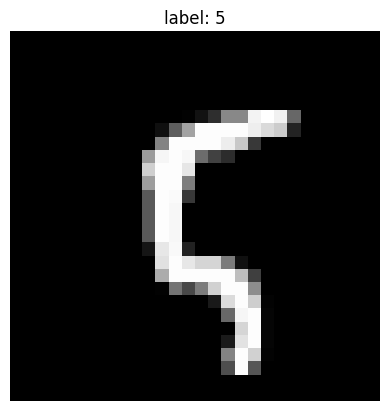

In [ ]:
import matplotlib.pyplot as plt
#plot first image
plt.imshow(x_train[100],cmap="gray")
plt.title(f"label: {y_train[0]}") #show the label
plt.axis("off")
plt.show()

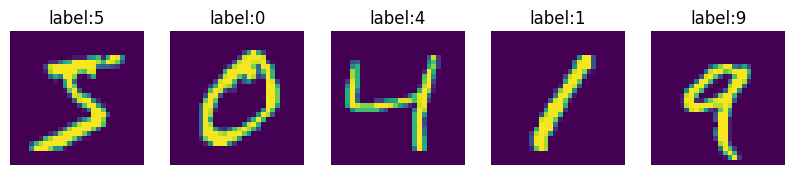

In [ ]:
#show first 5 images with labels
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(x_train[i])
  plt.title(f"label:{y_train[i]}")
  plt.axis("off")
plt.show()


In [ ]:
#step2: normalize values (0 to 1)
train_images=x_train/255.0
test_images=x_test/2555.0

In [ ]:
#step=3: add channel dimension(important for CNN)
train_images=train_images.reshape((60000,28,28,1))
test_images=test_images.reshape((10000,28,28,1))

In [ ]:
from tensorflow.keras import layers,models

model=models.Sequential([
    layers.Conv2D(16,(3,3),activation="relu",input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(32,activation="relu"),
    layers.Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#step5: compile model
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])


#step6: train model
model.fit(train_images,train_labels,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9368 - loss: 0.2171
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9775 - loss: 0.0755
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9827 - loss: 0.0564


In [ ]:
#step7: test model
test_loss,test_acc=model.evaluate(test_images,y_test)
# Delete the shadowed 'print' variable to restore the built-in function
del print
print('accuracy:',test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2515 - loss: 1.9781
accuracy: 0.2515000104904175


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Original Label: 1
Predicted Label: 1


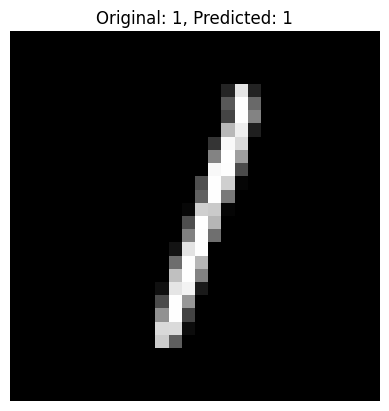

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = y_test[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [ ]:
# Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),   #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2),   #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images, y_train, epochs=3)
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, y_test)
print("Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9386 - loss: 0.2044
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9780 - loss: 0.0725
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9837 - loss: 0.0524
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8309 - loss: 1.7152
Accuracy: 0.8309000134468079
